# Pooled 3-Class Benchmark (train / val / test folds)

Benchmarks every feature family on the **pooled 1,966-sequence set** (Waymo train + val, 3-class)
using the **frozen fold assignment** in `data/cnn_2d_seq_fold.csv` — the same split Matt's CNN uses.

**Protocol:** fit on the **train** fold (1,376), select the winning feature-set/model on the
**val** fold (295), report final numbers on the **test** fold (295). Scalers are fit on train only.
Every family is joined by **seq_id**, so nothing depends on row position.

**Families** (each pooled from its training array + the `*_val` array produced by
`scripts/extract_val_features.py`): HOG, HSV, YOLO, Road_v1, Road_v2, VehicleOcc, Trend+Flow, BDD (frozen BDD100K-pretrained ResNet-50 scene embedding, 2048-d — see `bdd100k_backbone_embeddings/`).
If `CNN_2D.npy` (Matt's penultimate) and/or `av_embedding.npy` (AV-domain) are present, they're
added automatically and included in the "with vs without" comparison.

> **Note on the CNN feature:** the CNN was trained on the train fold, so its features on the
> *train* rows are in-sample for it — judge any improvement on **val/test**, where they're honest.
> All prior headline numbers (HOG 0.601 / Trend+Flow 0.648) were on the *old* 75/25 split of 1,604,
> so they are recomputed here on the new split and are not directly comparable to those.

## 0. Setup

In [11]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
FD   = PROJECT_ROOT / 'data' / 'processed' / 'waymo_e2e' / 'features'
FOLD_CSV = PROJECT_ROOT / 'data' / 'cnn_2d_seq_fold.csv'

CLASSES = ['straight', 'right-turn', 'left-turn']
RS = 42

FOLD  = pd.read_csv(FOLD_CSV).sort_values('cnn_row').reset_index(drop=True)
ORDER = FOLD['seq_id'].astype(str).tolist()        # canonical pooled order (== CNN_2D.npy row order)
y     = FOLD['class_label'].to_numpy()
foldv = FOLD['fold'].to_numpy()
tr, va, te = foldv == 'train', foldv == 'val', foldv == 'test'
print(f'pool={len(ORDER)}  train={tr.sum()}  val={va.sum()}  test={te.sum()}')
print('class balance (pool):', dict(pd.Series(y).value_counts().reindex(CLASSES)))

pool=1966  train=1376  val=295  test=295
class balance (pool): {'straight': 906, 'right-turn': 589, 'left-turn': 471}


## 1. Assemble every feature family by seq_id

Each family is built from its **training array** (keyed by its own seq_ids) plus the matching
`*_val` array (keyed by `seq_ids_val`), then laid out in the canonical pooled order. A family is
skipped with a warning if any file is missing.

In [12]:
def _load(name):
    return np.load(FD / name, allow_pickle=True)

def two_source(tr_arr, tr_sid, va_arr, va_sid):
    A = _load(tr_arr); ts = _load(tr_sid).astype(str)
    B = _load(va_arr); vs = _load(va_sid).astype(str)
    d = {s: A[i] for i, s in enumerate(ts)}
    for i, s in enumerate(vs): d[s] = B[i]          # val rows
    missing = [s for s in ORDER if s not in d]
    if missing:
        raise KeyError(f'{len(missing)} pool seqs have no feature row (e.g. {missing[:2]})')
    return np.stack([np.asarray(d[s], dtype=np.float32) for s in ORDER])

# family_name -> (train_arr, train_seqids, val_arr, val_seqids)
SOURCES = {
    'HOG':        ('hog.npy',                    'seq_ids.npy',                    'hog_val.npy',                'seq_ids_val.npy'),
    'HSV':        ('hsv.npy',                    'seq_ids.npy',                    'hsv_val.npy',                'seq_ids_val.npy'),
    'YOLO':       ('yolo.npy',                   'seq_ids.npy',                    'yolo_val.npy',               'seq_ids_val.npy'),
    'Road_v1':    ('road.npy',                   'seq_ids.npy',                    'road_val.npy',               'seq_ids_val.npy'),
    'Road_v2':    ('road_v2_3class.npy',         'seq_ids_3class.npy',             'road_v2_val.npy',            'seq_ids_val.npy'),
    'VehicleOcc': ('vehicle_occupancy_3class.npy','seq_ids_3class.npy',            'vehicle_occupancy_val.npy',  'seq_ids_val.npy'),
    'Trend+Flow': ('framediff_v2_3class.npy',    'framediff_v2_3class_seq_ids.npy','framediff_v2_val.npy',       'seq_ids_val.npy'),
    'BDD':        ('bdd100k_resnet50_scene_3class.npy', 'bdd100k_resnet50_scene_3class_seq_ids.npy', 'bdd100k_resnet50_scene_val_3class.npy', 'bdd100k_resnet50_scene_val_3class_seq_ids.npy'),
}

FAM = {}
for name, (ta, ts, vaa, vs) in SOURCES.items():
    try:
        FAM[name] = two_source(ta, ts, vaa, vs)
        print(f'  {name:12s} {FAM[name].shape}')
    except FileNotFoundError as e:
        print(f'  {name:12s} SKIPPED (missing file: {Path(str(e)).name})')

# ---- optional learned-feature families (single array in CNN-row order) ----
def single_source_cnnorder(arr_name):
    A = _load(arr_name)
    if len(A) != len(ORDER):
        raise ValueError(f'{arr_name}: {len(A)} rows != pool {len(ORDER)}')
    return np.asarray(A, dtype=np.float32)          # already in cnn_row order == ORDER

if (FD / 'CNN_2D.npy').exists():
    FAM['CNN'] = single_source_cnnorder('CNN_2D.npy')
    print(f'  {"CNN":12s} {FAM["CNN"].shape}  (Matt penultimate)')
    if (FD / 'labels_CNN_2D.npy').exists():
        lc = _load('labels_CNN_2D.npy').astype(str)
        # labels_CNN_2D is integer-encoded in some exports; only cross-check if it is string labels
        if lc.dtype.kind in 'US' and set(lc[:5]).issubset(set(CLASSES)):
            print('   labels_CNN_2D matches fold labels:', bool((lc == y).all()))
else:
    print('  CNN          not present yet — run scripts/gen_cnn2d_split_csvs.py then CNN_2D.ipynb')

if (FD / 'av_embedding.npy').exists():
    # av_embedding is keyed by its own seq_ids -> join by seq_id
    A = _load('av_embedding.npy'); s = _load('av_embedding_seq_ids.npy').astype(str)
    d = {sid: A[i] for i, sid in enumerate(s)}
    if all(sid in d for sid in ORDER):
        FAM['AV'] = np.stack([np.asarray(d[sid], np.float32) for sid in ORDER])
        print(f'  {"AV":12s} {FAM["AV"].shape}  (AV-domain embedding)')

print('\nfamilies available:', list(FAM))

  HOG          (1966, 5796)
  HSV          (1966, 34)
  YOLO         (1966, 32)
  Road_v1      (1966, 8)
  Road_v2      (1966, 10)
  VehicleOcc   (1966, 7)
  Trend+Flow   (1966, 22)
  BDD          (1966, 2048)
  CNN          (1966, 64)  (Matt penultimate)
   labels_CNN_2D matches fold labels: True

families available: ['HOG', 'HSV', 'YOLO', 'Road_v1', 'Road_v2', 'VehicleOcc', 'Trend+Flow', 'BDD', 'CNN']


## 2. Benchmark — fit on train, select on val, report on test

In [13]:
def bench(combo):
    X  = np.concatenate([FAM[f] for f in combo], axis=1)
    sc = StandardScaler().fit(X[tr])
    Xtr, Xva, Xte = sc.transform(X[tr]), sc.transform(X[va]), sc.transform(X[te])
    row = {'features': ' + '.join(combo), 'dims': X.shape[1], '_combo': combo}
    for mname in ('SVM', 'RF'):
        if mname == 'RF':   # trees are scale-invariant -> raw, mirrors the v3 benchmark
            m = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RS, n_jobs=-1)
            m.fit(X[tr], y[tr]); pv, pt = m.predict(X[va]), m.predict(X[te])
        else:
            m = SVC(kernel='rbf', class_weight='balanced', random_state=RS)
            m.fit(Xtr, y[tr]); pv, pt = m.predict(Xva), m.predict(Xte)
        row[f'{mname}_val_f1']  = f1_score(y[va], pv, labels=CLASSES, average='macro')
        row[f'{mname}_test_f1'] = f1_score(y[te], pt, labels=CLASSES, average='macro')
        row[f'{mname}_test_acc']= accuracy_score(y[te], pt)
    return row

has = lambda *fs: all(f in FAM for f in fs)
combos = [[f] for f in FAM]                                  # every family alone
combos += [c for c in [
    ['HOG','Trend+Flow'],
    ['HOG','HSV','YOLO','Road_v2','VehicleOcc','Trend+Flow'],           # all classical
] if has(*c)]
if 'BDD' in FAM:   # frozen BDD100K ResNet-50 scene embedding (leakage-clean, like MoViNet)
    combos += [c for c in [
        ['Trend+Flow','BDD'],
        ['HOG','Trend+Flow','BDD'],
    ] if has(*c)]
if 'CNN' in FAM:   # ['CNN'] alone is already in the per-family loop above — don't re-add it
    combos += [c for c in [
        ['Trend+Flow','CNN'],
        ['HOG','Trend+Flow','CNN'],
        ['HOG','HSV','YOLO','Road_v2','VehicleOcc','Trend+Flow','CNN'],  # all classical + CNN
    ] if has(*c)]

rows = []
for i, c in enumerate(combos):
    print(f'  [{i+1}/{len(combos)}] {" + ".join(c)} ...', flush=True)   # progress (HOG combos are slow)
    rows.append(bench(c))
results = pd.DataFrame(rows)

maj = pd.Series(y[tr]).value_counts(normalize=True).max()
print(f'\nmajority-class baseline (train prior): {maj:.3f}\n')
show = results.drop(columns=['_combo']).sort_values('RF_test_f1', ascending=False).reset_index(drop=True)
pd.set_option('display.width', 200)
print(show.to_string(index=False,
      formatters={c: '{:.3f}'.format for c in show.columns if c.endswith(('_f1','_acc'))}))

  [1/16] HOG ...
  [2/16] HSV ...
  [3/16] YOLO ...
  [4/16] Road_v1 ...
  [5/16] Road_v2 ...
  [6/16] VehicleOcc ...
  [7/16] Trend+Flow ...
  [8/16] BDD ...
  [9/16] CNN ...
  [10/16] HOG + Trend+Flow ...
  [11/16] HOG + HSV + YOLO + Road_v2 + VehicleOcc + Trend+Flow ...
  [12/16] Trend+Flow + BDD ...
  [13/16] HOG + Trend+Flow + BDD ...
  [14/16] Trend+Flow + CNN ...
  [15/16] HOG + Trend+Flow + CNN ...
  [16/16] HOG + HSV + YOLO + Road_v2 + VehicleOcc + Trend+Flow + CNN ...

majority-class baseline (train prior): 0.461

                                                  features  dims SVM_val_f1 SVM_test_f1 SVM_test_acc RF_val_f1 RF_test_f1 RF_test_acc
                                                Trend+Flow    22      0.514       0.526        0.556     0.611      0.607       0.671
                                          Trend+Flow + CNN    86      0.624       0.575        0.597     0.613      0.597       0.631
                                    HOG + Trend+Flow + CNN  5882    

## 3. Final model (best val among CNN-free) → held-out test, plus CNN ablation

Final classical model (best val among hand-crafted combos): Trend+Flow / RF  (val f1=0.611)

TEST accuracy=0.671  macro-F1=0.607  (majority baseline 0.461)

              precision    recall  f1-score   support

    straight       0.86      0.88      0.87       136
  right-turn       0.54      0.62      0.58        88
   left-turn       0.42      0.32      0.37        71

    accuracy                           0.67       295
   macro avg       0.61      0.61      0.61       295
weighted avg       0.66      0.67      0.66       295

CNN ablation (RF, test macro-F1):  Trend+Flow = 0.607   Trend+Flow + CNN = 0.597   delta = -0.010   (~0.05 = 1 SE on n=295)
BDD ablation (RF, test macro-F1):  Trend+Flow = 0.607   Trend+Flow + BDD = 0.464   delta = -0.142   (~0.05 = 1 SE on n=295)

[val-noise note] unrestricted val selection would pick HOG + Trend+Flow + BDD / RF (val 0.623) which scores only 0.510 on test - an example of validation-selection noise at n=295; see read-out.


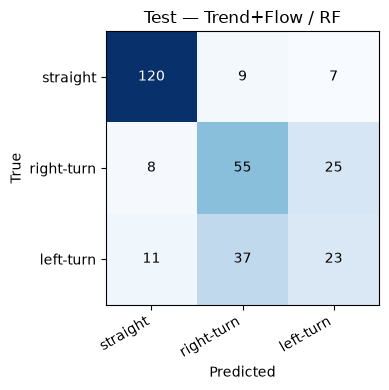

In [14]:
# Selection protocol: the FINAL classical model is chosen by val macro-F1 among HAND-CRAFTED
# (classical) combos only. Frozen pretrained embeddings (BDD, MoViNet) are leakage-clean but are
# evaluated as ADD-ON ablations to the selected base, and the CNN (val-trained) is ablation-only.
EXCLUDE_FROM_SELECTION = ('CNN', 'BDD')
def excluded(cmb): return any(f in cmb for f in EXCLUDE_FROM_SELECTION)

best = None  # (val_f1, combo_list, model)
for _, r in results.iterrows():
    if excluded(r['_combo']): continue
    for mname in ('SVM', 'RF'):
        cand = (r[f'{mname}_val_f1'], r['_combo'], mname)
        if best is None or cand[0] > best[0]: best = cand
val_f1, combo, mdl = best
feats = ' + '.join(combo)
print(f'Final classical model (best val among hand-crafted combos): {feats} / {mdl}  (val f1={val_f1:.3f})')

def fit_predict_test(cmb, model):
    X = np.concatenate([FAM[f] for f in cmb], axis=1)
    if model == 'RF':
        m = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RS, n_jobs=-1).fit(X[tr], y[tr])
        return m.predict(X[te])
    sc = StandardScaler().fit(X[tr])
    m = SVC(kernel='rbf', class_weight='balanced', random_state=RS).fit(sc.transform(X[tr]), y[tr])
    return m.predict(sc.transform(X[te]))

pt = fit_predict_test(combo, mdl)
test_f1 = f1_score(y[te], pt, labels=CLASSES, average='macro')
print(f'\nTEST accuracy={accuracy_score(y[te],pt):.3f}  macro-F1={test_f1:.3f}  (majority baseline {maj:.3f})\n')
print(classification_report(y[te], pt, labels=CLASSES, zero_division=0))

# --- ablations on the SAME base, judged on TEST ---
for extra in ('CNN', 'BDD'):
    if extra in FAM:
        pe = fit_predict_test(combo + [extra], mdl)
        fe = f1_score(y[te], pe, labels=CLASSES, average='macro')
        print(f'{extra} ablation ({mdl}, test macro-F1):  {feats} = {test_f1:.3f}   '
              f'{feats} + {extra} = {fe:.3f}   delta = {fe - test_f1:+.3f}   (~0.05 = 1 SE on n={te.sum()})')

# --- transparency: what unrestricted val-selection would have picked (val-noise illustration) ---
ub = None
for _, r in results.iterrows():
    if 'CNN' in r['_combo']: continue          # CNN stays out (val leakage); BDD allowed here
    for mname in ('SVM', 'RF'):
        cand = (r[f'{mname}_val_f1'], r['_combo'], mname, r[f'{mname}_test_f1'])
        if ub is None or cand[0] > ub[0]: ub = cand
print(f"\n[val-noise note] unrestricted val selection would pick {' + '.join(ub[1])} / {ub[2]} "
      f"(val {ub[0]:.3f}) which scores only {ub[3]:.3f} on test - an example of validation-selection "
      f"noise at n=295; see read-out.")

OUT = PROJECT_ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
cm = confusion_matrix(y[te], pt, labels=CLASSES)
fig, ax = plt.subplots(figsize=(4.5,4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'Test — {feats} / {mdl}')
for i in range(3):
    for j in range(3):
        ax.text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.tight_layout()
fig.savefig(OUT / 'benchmark_confusion_final_classical.png', dpi=200, bbox_inches='tight')
plt.show()


## 4. Read-out

- **Selection protocol:** the final *classical* model is the best val macro-F1 among hand-crafted
  combos → **Trend+Flow / RF** (val 0.611; test acc 0.671 / macro-F1 0.607). Frozen pretrained
  embeddings (**BDD**, **MoViNet**) are leakage-clean and evaluated as add-on ablations to that base;
  the **CNN** (early-stopped on the val fold) is ablation-only and never eligible for selection.
- **MoViNet stack = final best.** Trend+Flow + MoViNet / SVM reaches **acc 0.746 / macro-F1 0.693**
  on held-out test (Section 5), +0.086 F1 over the classical best — video transfer features add
  complementary signal to explicit motion features.
- **BDD does not help.** Alone: test F1 ≈ 0.46; stacked with Trend+Flow it *drops* the base
  (0.607 → ≈0.46). A driving-domain *single-frame* embedding still lacks the motion signal —
  consistent with the central finding.
- **Validation-selection noise (documented deliberately):** unrestricted val selection would pick
  HOG + Trend+Flow + BDD / RF (val 0.623), which collapses to 0.510 on test. With n=295 per fold,
  ~0.05 macro-F1 ≈ 1 SE — this is why we restrict selection to compact hand-crafted combos and
  report the unrestricted pick transparently rather than silently chasing val.
- **CNN ablation:** judge on test only (the one fold the CNN never saw); read deltas within ±0.05
  as "no clear gain."
- Note: rbf-SVM on raw 5,796-dim HOG is degenerate (near-identical test F1 across HOG combos) —
  trust the **RF** column for HOG rows, or PCA-reduce HOG before the SVM.


## 5. MoViNet stack for the class update — current best vs. Trend+Flow + MoViNet

Frozen **MoViNet-A0 (stream, Kinetics-600)** embeddings, cached by `CNN_3D_v2.ipynb`, stacked with
the Trend+Flow temporal features. These are the *frozen backbone* embeddings (leakage-free) — not the
trained head's `dense_hidden`. Files live in
`data/processed/waymo_e2e/CNN_3D_v2/embedding_cache/movinet_a0_stream_{train,val,test}_embeddings.npy`
(gitignored — pull from the team Drive, like the other feature arrays). This section is self-contained
and does not change the benchmark/selection above; it just renders the two confusion matrices we present.

MoViNet embedding: (1966, 480)
Trend+Flow / RF                macro-F1=0.607  acc=0.671  recall str/right/left = 0.88/0.62/0.32  |  train 0.48s  inference 0.137 ms/sample (cached features)
Trend+Flow + MoViNet / SVM     macro-F1=0.693  acc=0.746  recall str/right/left = 0.94/0.67/0.46  |  train 0.20s  inference 0.230 ms/sample (cached features)


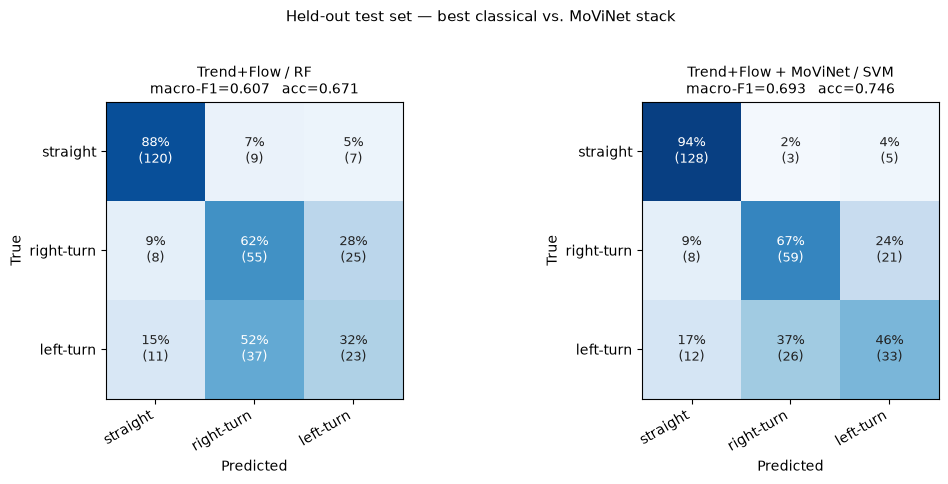

In [15]:
# --- frozen MoViNet-A0 embedding, laid out in the pooled ORDER (by seq_id) ---
import time
MOVI_DIR = PROJECT_ROOT / 'data' / 'processed' / 'waymo_e2e' / 'CNN_3D_v2' / 'embedding_cache'

def _load_npy(p):
    return np.load(p, allow_pickle=True)

def load_movinet(order):
    d = {}
    for split in ('train', 'val', 'test'):
        arr  = _load_npy(MOVI_DIR / f'movinet_a0_stream_{split}_embeddings.npy')
        sids = FOLD[FOLD['fold'] == split].sort_values('cnn_row')['seq_id'].astype(str).tolist()
        assert len(sids) == len(arr), f'{split}: {len(sids)} fold seqs vs {len(arr)} embedding rows'
        d.update(zip(sids, arr))
    missing = [s for s in order if s not in d]
    assert not missing, f'{len(missing)} pool seqs have no MoViNet row (e.g. {missing[:2]})'
    return np.stack([np.asarray(d[s], np.float32) for s in order])

MOVI = load_movinet(ORDER)
print('MoViNet embedding:', MOVI.shape)

def _fit_predict_test_timed(X, model):
    if model == 'RF':
        m = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   random_state=RS, n_jobs=-1)
        t0 = time.perf_counter(); m.fit(X[tr], y[tr]); fit_s = time.perf_counter() - t0
        t0 = time.perf_counter(); p = m.predict(X[te]); pred_s = time.perf_counter() - t0
        return p, fit_s, pred_s
    sc = StandardScaler().fit(X[tr])
    m = SVC(kernel='rbf', class_weight='balanced', random_state=RS)
    t0 = time.perf_counter(); m.fit(sc.transform(X[tr]), y[tr]); fit_s = time.perf_counter() - t0
    t0 = time.perf_counter(); p = m.predict(sc.transform(X[te])); pred_s = time.perf_counter() - t0
    return p, fit_s, pred_s

TF = FAM['Trend+Flow']
PANELS = [
    ('Trend+Flow / RF',            TF,                                  'RF'),
    ('Trend+Flow + MoViNet / SVM', np.concatenate([TF, MOVI], axis=1),  'SVM'),
]

OUT = PROJECT_ROOT / 'outputs'; OUT.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
for ax, (title, X, mdl) in zip(axes, PANELS):
    p, fit_s, pred_s = _fit_predict_test_timed(X, mdl)
    f1  = f1_score(y[te], p, labels=CLASSES, average='macro')
    acc = accuracy_score(y[te], p)
    cm  = confusion_matrix(y[te], p, labels=CLASSES)
    cmn = cm / cm.sum(axis=1, keepdims=True)
    im  = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
    ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{title}\nmacro-F1={f1:.3f}   acc={acc:.3f}', fontsize=10)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{cmn[i,j]*100:.0f}%\n({cm[i,j]})', ha='center', va='center',
                    color='white' if cmn[i,j] > 0.5 else '#222', fontsize=9)
    print(f'{title:30s} macro-F1={f1:.3f}  acc={acc:.3f}  '
          f'recall str/right/left = {cmn[0,0]:.2f}/{cmn[1,1]:.2f}/{cmn[2,2]:.2f}  |  '
          f'train {fit_s:.2f}s  inference {pred_s*1000/te.sum():.3f} ms/sample (cached features)')

fig.suptitle('Held-out test set — best classical vs. MoViNet stack', y=1.02, fontsize=11)
plt.tight_layout()
fig.savefig(OUT / 'confusion_dual_trendflow_vs_movinet.png', dpi=200, bbox_inches='tight')
plt.show()


## 6. Figure — "Motion is the signal" (slide 10 / paper)

Regenerates the per-family bar chart **from this notebook's `results` table** plus MoViNet rows computed here, so the chart and the results table can never disagree. Also exports `benchmark_pooled_3class.csv` and the PNG to `outputs/`.


In [ ]:
# --- MoViNet rows (val + test, both models), evaluated identically to bench() ---
def bench_arrays(name, X):
    sc = StandardScaler().fit(X[tr])
    row = {'features': name, 'dims': X.shape[1], '_combo': [name]}
    for mname in ('SVM', 'RF'):
        if mname == 'RF':
            m = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RS, n_jobs=-1)
            m.fit(X[tr], y[tr]); pv, pt_ = m.predict(X[va]), m.predict(X[te])
        else:
            m = SVC(kernel='rbf', class_weight='balanced', random_state=RS)
            m.fit(sc.transform(X[tr]), y[tr]); pv, pt_ = m.predict(sc.transform(X[va])), m.predict(sc.transform(X[te]))
        row[f'{mname}_val_f1']  = f1_score(y[va], pv, labels=CLASSES, average='macro')
        row[f'{mname}_test_f1'] = f1_score(y[te], pt_, labels=CLASSES, average='macro')
        row[f'{mname}_test_acc']= accuracy_score(y[te], pt_)
    return row

movi_rows = pd.DataFrame([
    bench_arrays('MoViNet', MOVI),
    bench_arrays('Trend+Flow + MoViNet', np.concatenate([FAM['Trend+Flow'], MOVI], axis=1)),
])
full = pd.concat([results, movi_rows], ignore_index=True)
print(movi_rows.drop(columns=['_combo']).to_string(index=False,
      formatters={c: '{:.3f}'.format for c in movi_rows.columns if c.endswith(('_f1','_acc'))}))

# export the complete table (single source of truth for slides + paper)
exp = full.drop(columns=['_combo'])
exp.to_csv(FD / 'benchmark_pooled_3class.csv', index=False)
print('\nsaved', FD / 'benchmark_pooled_3class.csv')

# --- bar chart: best-of-SVM/RF TEST ACCURACY per family, vs the 0.461 majority baseline ---
# (accuracy bars so the majority-class baseline line lives on its own metric; the macro-F1
#  ordering is the same — full numbers in benchmark_pooled_3class.csv)
MOTION = {'Trend+Flow', 'MoViNet', 'Trend+Flow + MoViNet'}
LABELS = {
    'Trend+Flow + MoViNet': 'Trend+Flow + MoViNet (stack)', 'MoViNet': 'MoViNet (video)',
    'CNN': '2D CNN embedding', 'BDD': 'BDD100K ResNet-50', 'Road_v2': 'Road geometry',
    'VehicleOcc': 'Vehicle occupancy',
}
fams = ['Trend+Flow + MoViNet', 'MoViNet', 'Trend+Flow', 'CNN', 'HOG', 'BDD', 'HSV', 'Road_v2', 'YOLO', 'VehicleOcc']
sub = exp.set_index('features')
vals = {f: max(sub.loc[f, 'SVM_test_acc'], sub.loc[f, 'RF_test_acc']) for f in fams}
order_f = sorted(fams, key=lambda f: vals[f])

fig, ax = plt.subplots(figsize=(9, 5.2))
ys = range(len(order_f))
colors = ['#ff7f0e' if f in MOTION else '#1f77b4' for f in order_f]
ax.barh(list(ys), [vals[f] for f in order_f], color=colors)
for i, f in enumerate(order_f):
    ax.text(vals[f] + 0.006, i, f'{vals[f]:.3f}', va='center', fontsize=9)
ax.set_yticks(list(ys)); ax.set_yticklabels([LABELS.get(f, f) for f in order_f])
maj_acc = maj  # majority-class accuracy from the train prior (0.461)
ax.axvline(maj_acc, ls='--', c='gray', lw=1)
ax.text(maj_acc + 0.005, len(order_f) - 0.55, f'majority-class baseline {maj_acc:.3f}',
        fontsize=8, color='gray')
ax.set_xlabel('Test accuracy (best of SVM / RF per family)')
ax.set_title('Motion is the signal: temporal and video features dominate')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#ff7f0e', label='Temporal / video (motion)'),
                   Patch(color='#1f77b4', label='Single-frame / appearance')], loc='lower right', fontsize=9)
ax.set_xlim(0, max(vals.values()) + 0.06)
plt.tight_layout()
fig.savefig(OUT / 'motion_is_the_signal_pooled.png', dpi=200, bbox_inches='tight')
plt.show()
